<a href="https://colab.research.google.com/github/ayobami4/TechCrush-Cohort-8_Data-Science/blob/main/Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Insurance Charges Implementation

## Collecting the data

### Importing the pandas library

In [ ]:
import pandas as pd

### Importing the dataset

In [ ]:
df = pd.read_csv("insurance.csv")

## Understanding the data

### Viewing the first few rows in the dataset

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Viewing the total number of rows and columns in the dataset

In [ ]:
df.shape

(1338, 7)

### Inspecting the properties of the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Inspecting the summary statistics of the dataset

In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Viewing the last few rows in the dataset

In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


### Viewing a random sample of rows in the dataset

In [ ]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
952,30,female,28.405,1,no,northwest,4527.18295
156,48,male,24.420,0,yes,southeast,21223.67580
291,29,male,29.640,1,no,northeast,20277.80751
374,20,male,33.330,0,no,southeast,1391.52870
91,53,female,24.795,1,no,northwest,10942.13205


### Checking for missing data

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Checking for duplicates

In [ ]:
df.duplicated().sum()

np.int64(1)

### Observing the frequency of each categorical data

In [ ]:
# Observation for sex category
df.sex.value_counts()

,count
sex,
male,676
female,662


In [ ]:
# Observation for smoker category
df.smoker.value_counts()

,count
smoker,
no,1064
yes,274


In [ ]:
# Observation for region category
df.region.value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


## Investigating the data

In [ ]:
# Viewing the duplicated copy
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
# Comparing both duplicated records
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


## Cleaning the dataset

### Removing duplicated copy

In [ ]:
df.drop_duplicates(inplace=True)

### Verifying the cleaned dataset

In [ ]:
# Checking for duplicates in the cleaned dataset
df.duplicated().sum()

np.int64(0)

In [ ]:
# Viewing the total number of rows and columns in the cleaned dataset
df.shape

(1337, 7)

## Performing exploratory data analysis (EDA)

### Importing the matplotlib library

In [ ]:
import matplotlib.pyplot as plt

### Visualizing the distribution in insurance charges

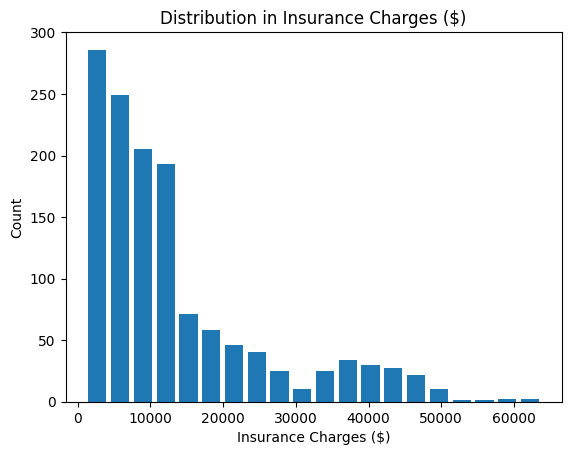

In [ ]:
# Plotting a histogram
plt.hist(df.charges, bins=20, rwidth=0.8)
plt.title('Distribution in Insurance Charges ($)')
plt.xlabel('Insurance Charges ($)')
plt.ylabel('Count')
plt.show()

### Visualizing the relationship between age and insurance charges

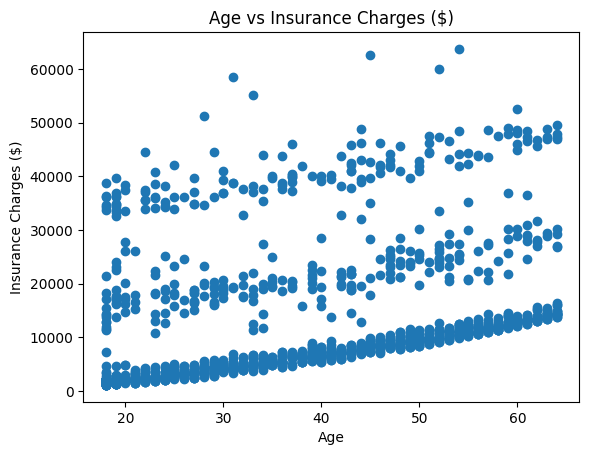

In [ ]:
# Plotting a scatter plot
plt.scatter(df.age, df.charges)
plt.title('Age vs Insurance Charges ($)')
plt.xlabel('Age')
plt.ylabel('Insurance Charges ($)')
plt.show()

### Importing the seaborn library

In [ ]:
import seaborn as sns

### Visualizing how insurance charges differ across smoking status

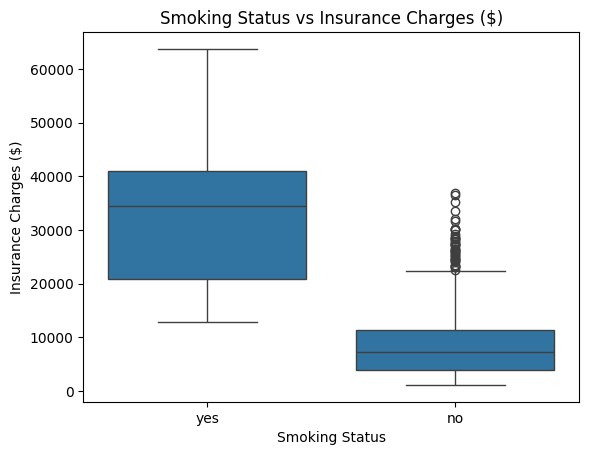

In [ ]:
# Plotting a box plot
sns.boxplot(x=df.smoker, y=df.charges)
plt.title('Smoking Status vs Insurance Charges ($)')
plt.xlabel('Smoking Status')
plt.ylabel('Insurance Charges ($)')
plt.show()

### Visualizing the relationship between bmi and insurance charges

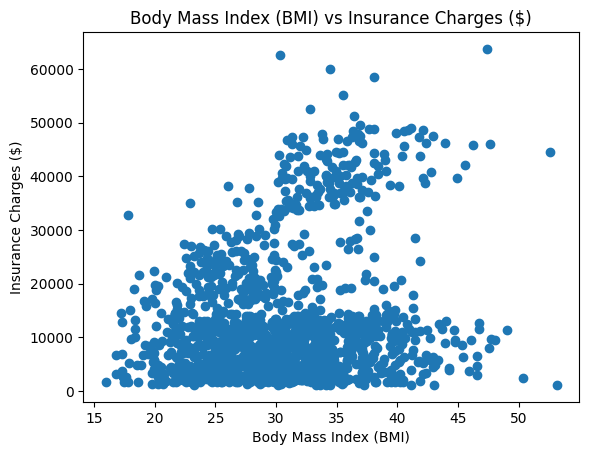

In [ ]:
# Plotting a scatter plot
plt.scatter(df.bmi, df.charges)
plt.title('Body Mass Index (BMI) vs Insurance Charges ($)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Insurance Charges ($)')
plt.show()

### Finding each number of children by average insurance charges

In [ ]:
children_charge_average = df.groupby('children')['charges'].mean()
children_charge_average

,charges
children,
0,12384.695344
1,12731.171832
2,15073.563734
3,15355.318367
4,13850.656311
5,8786.035247


### Observing the frequency of each number of children

In [ ]:
df.children.value_counts()

,count
children,
0,573
1,324
2,240
3,157
4,25
5,18


### Visualizing the average insurance charge for each number of children

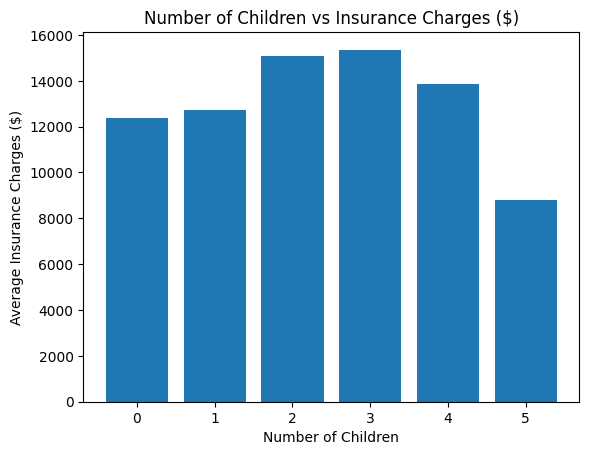

In [ ]:
# Plotting a bar plot
plt.bar(children_charge_average.index, children_charge_average.values)
plt.title('Number of Children vs Insurance Charges ($)')
plt.xlabel('Number of Children')
plt.ylabel('Average Insurance Charges ($)')
plt.show()

### Visualizing how insurance charges differ across sex categories

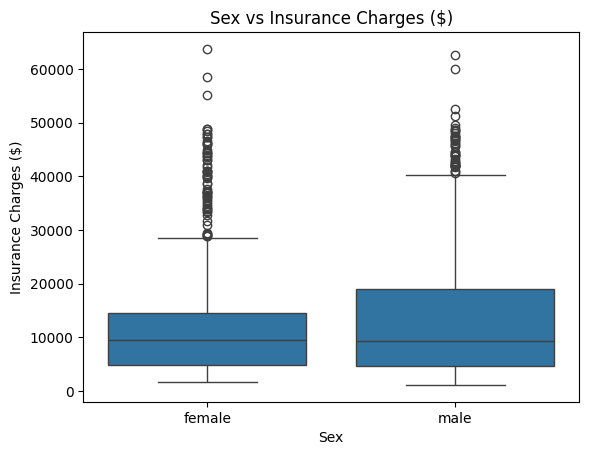

In [ ]:
# Plotting a box plot
sns.boxplot(x=df.sex, y=df.charges)
plt.title('Sex vs Insurance Charges ($)')
plt.xlabel('Sex')
plt.ylabel('Insurance Charges ($)')
plt.show()

### Visualizing how insurance charges differ across the regions

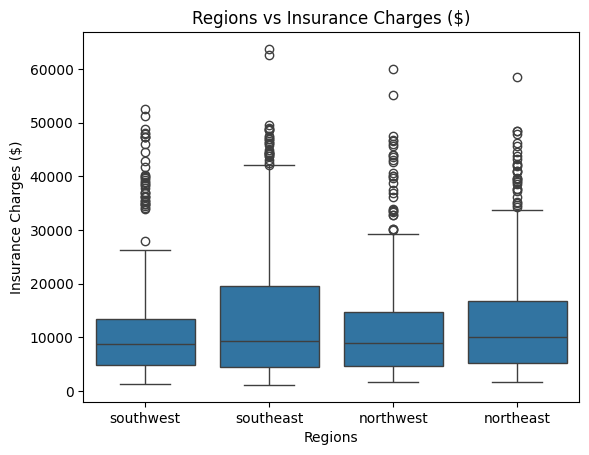

In [ ]:
# Plotting a box plot
sns.boxplot(x=df.region, y=df.charges)
plt.title('Regions vs Insurance Charges ($)')
plt.xlabel('Regions')
plt.ylabel('Insurance Charges ($)')
plt.show()

### Investigating potential outliers

In [ ]:
# Flagging observations for investigation of insurance charges using interquartile range (IQR)
q1 = df.charges.quantile(0.25)
q3 = df.charges.quantile(0.75)

iqr = q3 - q1

lower_boundary = q1 - (1.5 * iqr)
upper_boundary = q3 + (1.5 * iqr)

# Printing the results of the insurance charges' lower and upper boundaries
print(f'Lower boundary: {lower_boundary}, Upper boundary: {upper_boundary}')

Lower boundary: -13120.716174999998, Upper boundary: 34524.777625


In [ ]:
# Filtering the data to display every row whose insurance charges fall outside our lower and upper boundaries
charge_outliers = df[(df['charges'] < lower_boundary) | (df['charges'] > upper_boundary)]
charge_outliers

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1300,45,male,30.360,0,yes,southeast,62592.87309
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1313,19,female,34.700,2,yes,southwest,36397.57600


In [ ]:
# Observing the frequency of each group in the smoker category of potential charge outliers
charge_outliers.smoker.value_counts()

,count
smoker,
yes,136
no,3


In [ ]:
# Investigating high-charge smokers against other smokers
smokers = df[df['smoker'] == 'yes']
smokers.shape

(274, 7)

In [ ]:
# Continuing investigation using interquartile range (IQR)
smokers_q1 = smokers['charges'].quantile(0.25)
smokers_q3 = smokers['charges'].quantile(0.75)

smokers_iqr = smokers_q3 - smokers_q1

smokers_lower_boundary = smokers_q1 - (1.5 * smokers_iqr)
smokers_upper_boundary = smokers_q3 + (1.5 * smokers_iqr)

# Printing the results of the smokers' lower and upper boundaries
print(f'Smokers lower boundary: {smokers_lower_boundary}, Smokers upper boundary: {smokers_upper_boundary}')

Smokers lower boundary: -9463.200381249997, Smokers upper boundary: 71308.65186874999


In [ ]:
# Investigating high-charge non-smokers against other non-smokers
non_smokers = df[df['smoker'] == 'no']
non_smokers.shape

(1063, 7)

In [ ]:
# Continuing investigation using interquartile range (IQR)
non_smokers_q1 = non_smokers['charges'].quantile(0.25)
non_smokers_q3 = non_smokers['charges'].quantile(0.75)

non_smokers_iqr = non_smokers_q3 - non_smokers_q1

non_smokers_lower_boundary = non_smokers_q1 - (1.5 * non_smokers_iqr)
non_smokers_upper_boundary = non_smokers_q3 + (1.5 * non_smokers_iqr)

# Printing the results of the non-smokers' lower and upper boundaries
print(f'Non-smokers lower boundary: {non_smokers_lower_boundary}, Non-smokers upper boundary: {non_smokers_upper_boundary}')

Non-smokers lower boundary: -7072.319899999999, Non-smokers upper boundary: 22424.222499999996


In [ ]:
# Filtering the data to display every non-smoker observation whose charges fall outside our non-smokers' lower and upper boundaries
non_smoker_outliers = non_smokers[(non_smokers['charges'] < non_smokers_lower_boundary) | (non_smokers['charges'] > non_smokers_upper_boundary)]
non_smoker_outliers

,age,sex,bmi,children,smoker,region,charges
9,60,female,25.840,0,no,northwest,28923.13692
62,64,male,24.700,1,no,northwest,30166.61817
115,60,male,28.595,0,no,northeast,30259.99556
138,54,female,31.900,3,no,southeast,27322.73386
140,34,male,22.420,2,no,northeast,27375.90478
219,24,female,23.210,0,no,southeast,25081.76784
227,58,female,41.910,0,no,southeast,24227.33724
242,55,female,26.800,1,no,southwest,35160.13457
245,54,male,30.020,0,no,northwest,24476.47851
289,52,male,26.400,3,no,southeast,25992.82104


In [ ]:
# Verifying the number of rows in non_smoker_outliers
non_smoker_outliers.shape[0]

46

## Preprocessing the data

### Separating the dataset into independent variable (X) and dependent variable (y)

In [ ]:
# Creating our independent variable (X)
X = df.drop('charges', axis='columns')
X

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [ ]:
# Creating our dependent variable (y)
y = df.charges
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


### Splitting the data into training and testing sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Checking the number of rows and columns in X_train, X_test, y_train, and y_test respectively
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, and y_test: {y_test.shape}')

X_train: (1069, 6), X_test: (268, 6), y_train: (1069,), and y_test: (268,)


### Encoding Categorical variables

In [ ]:
# Replacing categorical sex data with binary codes for X_train
X_train['sex'] = X_train['sex'].map({'female': 0, 'male': 1})

# Verifying affected data
X_train['sex']

,sex
1114,1
968,1
599,0
170,1
275,0
...,...
1096,0
1131,1
1295,1
861,0


In [ ]:
# Replacing categorical smoker data with binary codes for X_train
X_train['smoker'] = X_train['smoker'].map({'no': 0, 'yes': 1})

# Verifying affected data
X_train['smoker']

,smoker
1114,0
968,0
599,0
170,0
275,0
...,...
1096,1
1131,0
1295,0
861,0


In [ ]:
# Replacing categorical sex data with binary codes for X_test
X_test['sex'] = X_test['sex'].map({'female': 0, 'male': 1})

# Verifying affected data
X_test['sex']

,sex
900,1
1064,0
1256,0
298,1
237,1
...,...
534,1
542,0
760,0
1284,1


In [ ]:
# Replacing categorical smoker data with binary codes for X_test
X_test['smoker'] = X_test['smoker'].map({'no': 0, 'yes': 1})

# Verifying affected data
X_test['smoker']

,smoker
900,0
1064,0
1256,0
298,1
237,0
...,...
534,0
542,0
760,0
1284,1


In [ ]:
# Performing One-Hot Encoding on categorical region data
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer([('region', OneHotEncoder(drop='first'), ['region'])], remainder='passthrough')

In [ ]:
# Training ColumnTransformer on X_train
X_train = ct.fit_transform(X_train)

# Verifying the newly transformed data
X_train

array([[ 0.   ,  0.   ,  0.   , ..., 24.51 ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   , ..., 25.745,  2.   ,  0.   ],
       [ 1.   ,  0.   ,  0.   , ..., 37.525,  2.   ,  0.   ],
       ...,
       [ 0.   ,  0.   ,  1.   , ..., 22.   ,  1.   ,  0.   ],
       [ 0.   ,  0.   ,  1.   , ..., 28.   ,  3.   ,  0.   ],
       [ 0.   ,  1.   ,  0.   , ..., 35.86 ,  2.   ,  0.   ]])

In [ ]:
# Applying the trained ColumnTransformer on X_test
X_test = ct.transform(X_test)

# Verifying the newly transformed data
X_test

array([[ 0.   ,  0.   ,  0.   , ..., 22.515,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  1.   , ..., 25.6  ,  4.   ,  0.   ],
       [ 1.   ,  0.   ,  0.   , ..., 36.385,  3.   ,  0.   ],
       ...,
       [ 0.   ,  0.   ,  0.   , ..., 34.58 ,  2.   ,  0.   ],
       [ 0.   ,  0.   ,  1.   , ..., 36.3  ,  1.   ,  1.   ],
       [ 0.   ,  0.   ,  0.   , ..., 24.32 ,  0.   ,  0.   ]])

## Building our model

In [ ]:
# Importing LinearRegression
from sklearn.linear_model import LinearRegression

# Creating an instance of the model
lr = LinearRegression()

### Training our model

In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

### Testing our model

In [ ]:
lr.predict(X_test)

array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
        8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
        1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
        3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
        4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
        3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
        3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
        1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
        3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
        4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
        7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
        7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
        4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
        3.12447687e+04,  

### Evaluating our model performance

In [ ]:
lr.score(X_test, y_test)

0.8069287081198013

### Inspecting coefficients our model learned

In [ ]:
lr.coef_

array([ -391.76145478,  -838.91961573,  -659.13975155,   248.21072022,
        -101.54205399,   318.70144095,   533.0099888 , 23077.76459287])

In [ ]:
# Getting the exact feature order corresponding to the eight coefficients
ct.get_feature_names_out()

array(['region__region_northwest', 'region__region_southeast',
       'region__region_southwest', 'remainder__age', 'remainder__sex',
       'remainder__bmi', 'remainder__children', 'remainder__smoker'],
      dtype=object)

### Inspecting the intercept our model learned

In [ ]:
lr.intercept_

np.float64(-11092.65229594607)